<a href="https://colab.research.google.com/github/IanDiaz05/dashboard-integral/blob/main/examen_1_parcial_Jonathan_Alexander_Gonzalez_Romerol_%5BRegresion%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
library(dplyr)
library(ggplot2)

In [34]:
# Crear carpeta para extraer la base
dir.create("/content/datos", showWarnings = FALSE)

# Descomprimir el archivo
unzip(
  "/content/Life Expectancy Data.csv",
  exdir = "/content/datos"
)

# Mostrar los archivos extraídos
list.files("/content/datos", recursive = TRUE)

[1] "Life Expectancy Data.csv"

In [35]:
dat <- read.csv(
  "/content/datos/Life Expectancy Data.csv",
  check.names = FALSE
)

names(dat) <- trimws(names(dat))
dat <- dat[dat$Year == 2015, ]

head(dat)

# Seleccionar la respuesta y los predictores solicitados
dat <- dat %>%
  select(
    Country,
    `Life expectancy`,
    Status,
    `Adult Mortality`,
    `infant deaths`,
    Alcohol,
    `percentage expenditure`,
    `Hepatitis B`,
    Measles
  )

head(dat)

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,⋯,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
,<chr>,<int>,<chr>,<dbl>,<int>,<int>,<dbl>,<dbl>,<int>,<int>,⋯,<int>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,Afghanistan,2015,Developing,65.0,263,62,0.01,71.27962,65,1154,⋯,6,8.16,65,0.1,584.2592,33736494,17.2,17.3,0.479,10.1
17,Albania,2015,Developing,77.8,74,0,4.60,364.97523,99,0,⋯,99,6.00,99,0.1,3954.2278,28873,1.2,1.3,0.762,14.2
33,Algeria,2015,Developing,75.6,19,21,NA,0.00000,95,63,⋯,95,NA,95,0.1,4132.7629,39871528,6.0,5.8,0.743,14.4
49,Angola,2015,Developing,52.4,335,66,NA,0.00000,64,118,⋯,7,NA,64,1.9,3695.7937,2785935,8.3,8.2,0.531,11.4
65,Antigua and Barbuda,2015,Developing,76.4,13,0,NA,0.00000,99,0,⋯,86,NA,99,0.2,13566.9541,NA,3.3,3.3,0.784,13.9
81,Argentina,2015,Developing,76.3,116,8,NA,0.00000,94,0,⋯,93,NA,94,0.1,13467.1236,43417765,1.0,0.9,0.826,17.3


,Country,Life expectancy,Status,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles
,<chr>,<dbl>,<chr>,<int>,<int>,<dbl>,<dbl>,<int>,<int>
1,Afghanistan,65.0,Developing,263,62,0.01,71.27962,65,1154
17,Albania,77.8,Developing,74,0,4.60,364.97523,99,0
33,Algeria,75.6,Developing,19,21,NA,0.00000,95,63
49,Angola,52.4,Developing,335,66,NA,0.00000,64,118
65,Antigua and Barbuda,76.4,Developing,13,0,NA,0.00000,99,0
81,Argentina,76.3,Developing,116,8,NA,0.00000,94,0


In [36]:
# Porcentaje de valores faltantes por variable
porcentaje_na <- round(colMeans(is.na(dat)) * 100, 2)

porcentaje_na

Country        Life expectancy                 Status 
                  0.00                   0.00                   0.00 
       Adult Mortality          infant deaths                Alcohol 
                  0.00                   0.00                  96.72 
percentage expenditure            Hepatitis B                Measles 
                  0.00                   4.92                   0.00

In [37]:
# Eliminar Alcohol porque tiene más del 50 % de valores faltantes
dat <- dat %>%
  select(-Alcohol)

# Reemplazar los NA de Hepatitis B con su media
media_hepatitis <- mean(dat$`Hepatitis B`, na.rm = TRUE)

dat$`Hepatitis B`[
  is.na(dat$`Hepatitis B`)
] <- media_hepatitis

# Comprobar que ya no quedan valores faltantes
round(colMeans(is.na(dat)) * 100, 2)

# Mostrar la media utilizada
media_hepatitis

Country        Life expectancy                 Status 
                     0                      0                      0 
       Adult Mortality          infant deaths percentage expenditure 
                     0                      0                      0 
           Hepatitis B                Measles 
                     0                      0

[1] 82.42529

`geom_smooth()` using formula = 'y ~ x'


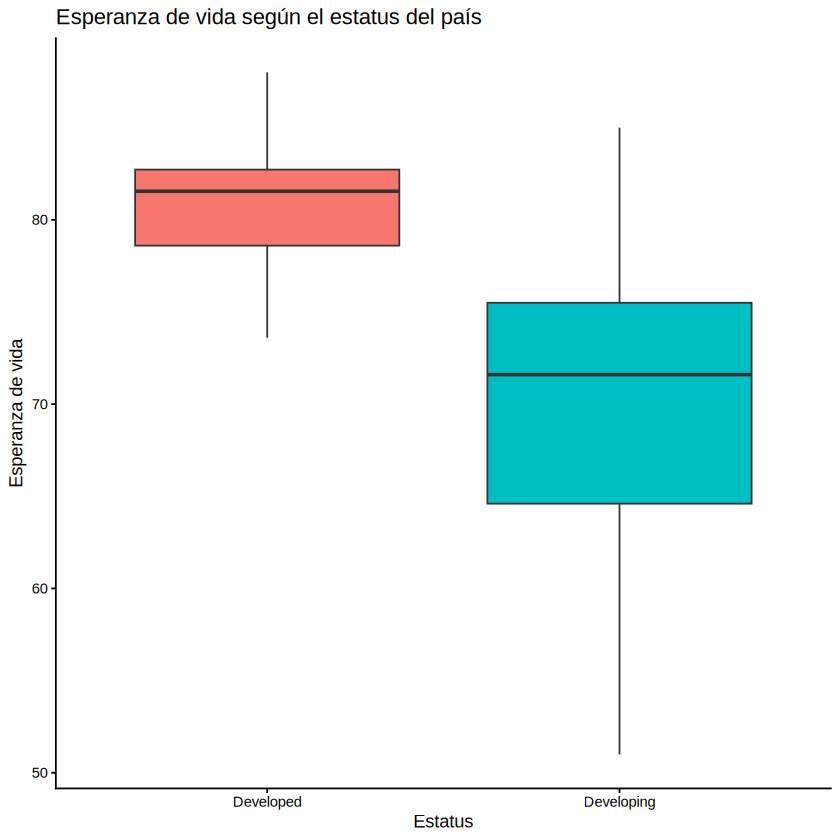

`geom_smooth()` using formula = 'y ~ x'


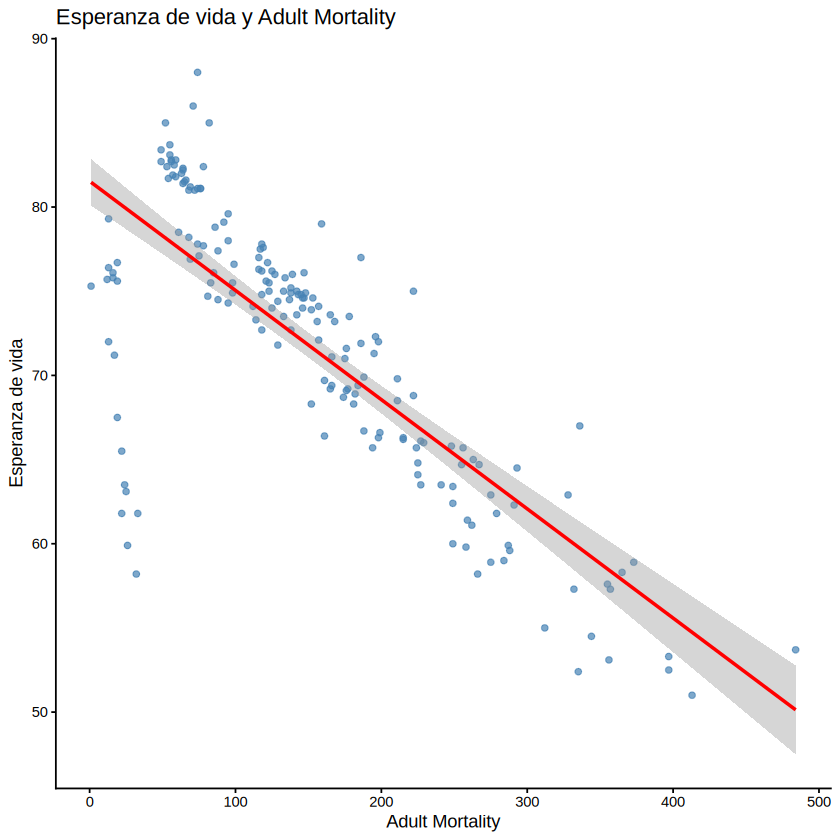

`geom_smooth()` using formula = 'y ~ x'


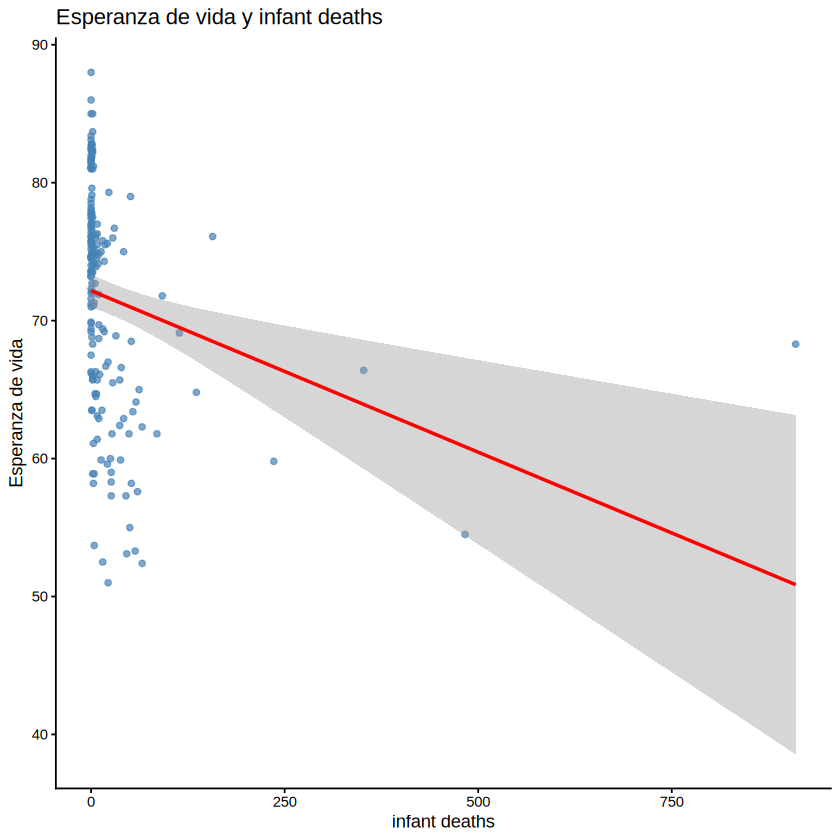

`geom_smooth()` using formula = 'y ~ x'


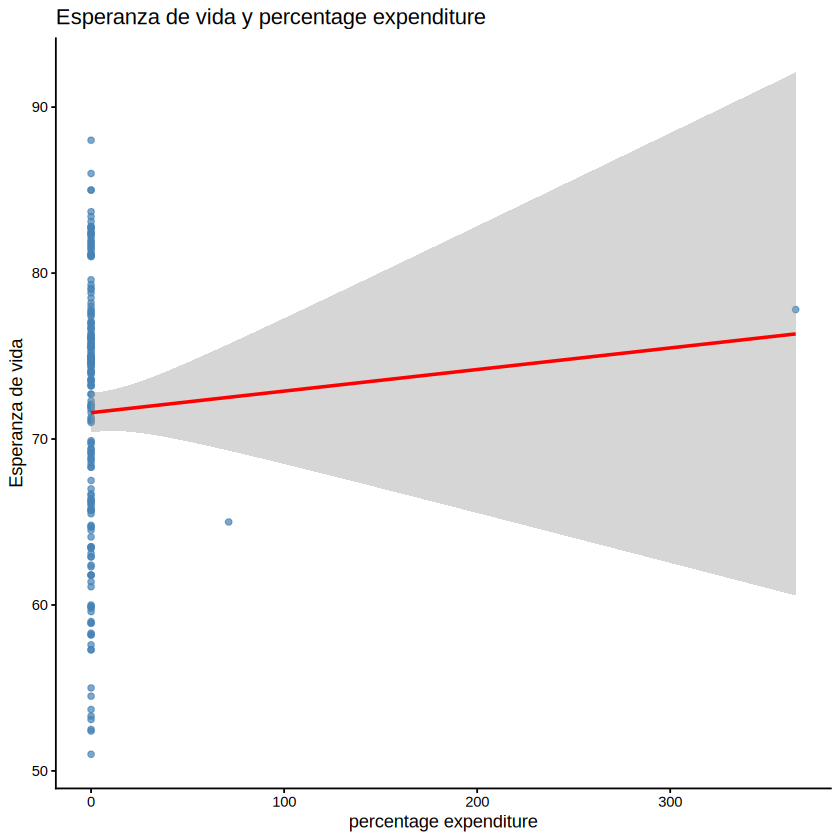

`geom_smooth()` using formula = 'y ~ x'


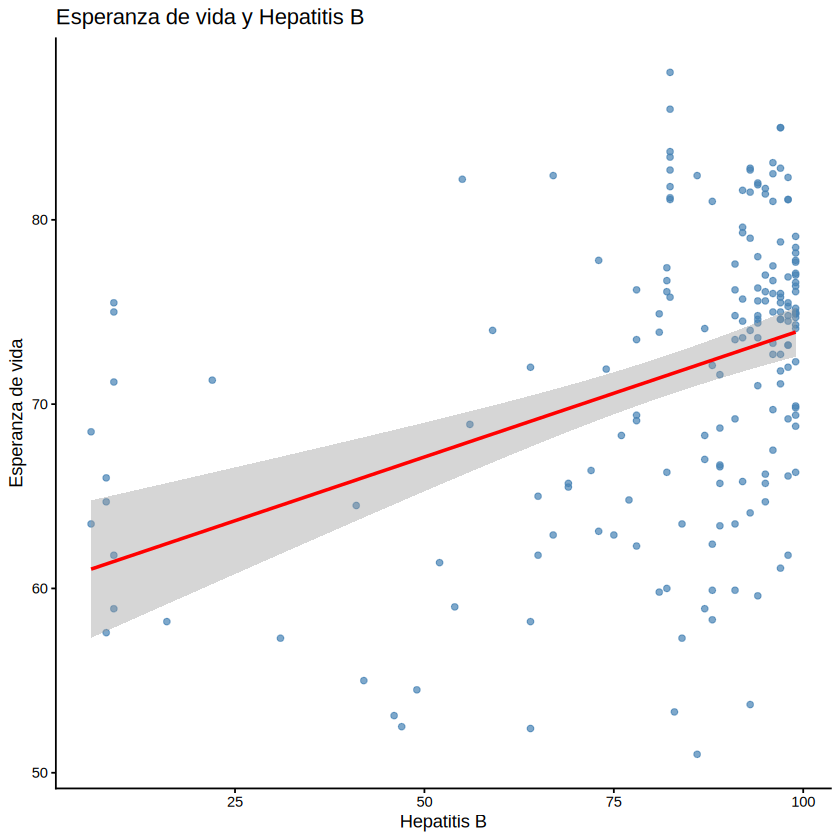

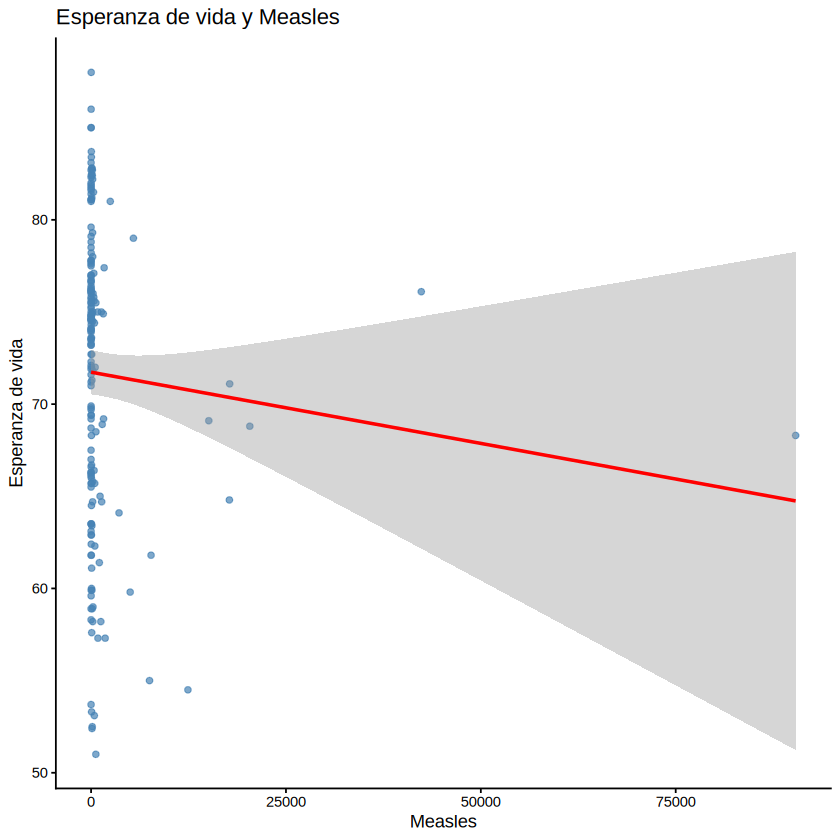

In [38]:
# Gráfica de Status, que es una variable categórica
ggplot(dat, aes(x = Status, y = `Life expectancy`, fill = Status)) +
  geom_boxplot() +
  theme_classic() +
  labs(
    title = "Esperanza de vida según el estatus del país",
    x = "Estatus",
    y = "Esperanza de vida"
  ) +
  theme(legend.position = "none")

# Predictores numéricos
predictores <- c(
  "Adult Mortality",
  "infant deaths",
  "percentage expenditure",
  "Hepatitis B",
  "Measles"
)

# Crear una gráfica de dispersión por predictor
for (variable in predictores) {
  grafica <- ggplot(
    dat,
    aes(x = .data[[variable]], y = `Life expectancy`)
  ) +
    geom_point(color = "steelblue", alpha = 0.7) +
    geom_smooth(method = "lm", se = TRUE, color = "red") +
    theme_classic() +
    labs(
      title = paste("Esperanza de vida y", variable),
      x = variable,
      y = "Esperanza de vida"
    )

  print(grafica)
}

In [39]:
# Ajustar el modelo de regresión lineal múltiple
modelo <- lm(
  `Life expectancy` ~
    Status +
    `Adult Mortality` +
    `infant deaths` +
    `percentage expenditure` +
    `Hepatitis B` +
    Measles,
  data = dat
)

# Mostrar los resultados
summary(modelo)


Call:
lm(formula = `Life expectancy` ~ Status + `Adult Mortality` + 
    `infant deaths` + `percentage expenditure` + `Hepatitis B` + 
    Measles, data = dat)

Residuals:
     Min       1Q   Median       3Q      Max 
-17.4838  -2.1256   0.0103   2.4140   9.4864 

Coefficients:
                           Estimate Std. Error t value Pr(>|t|)    
(Intercept)               7.791e+01  1.529e+00  50.951  < 2e-16 ***
StatusDeveloping         -5.493e+00  9.108e-01  -6.031 9.37e-09 ***
`Adult Mortality`        -5.082e-02  3.697e-03 -13.748  < 2e-16 ***
`infant deaths`          -1.483e-02  6.653e-03  -2.230    0.027 *  
`percentage expenditure`  5.450e-03  1.173e-02   0.465    0.643    
`Hepatitis B`             7.514e-02  1.419e-02   5.293 3.54e-07 ***
Measles                   1.003e-04  6.981e-05   1.437    0.153    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 4.33 on 176 degrees of freedom
Multiple R-squared:  0.7253,	Adjusted R-squared:  0.

In [40]:
# Modelo final con los predictores significativos
modelo_final <- lm(
  `Life expectancy` ~
    Status +
    `Adult Mortality` +
    `infant deaths` +
    `Hepatitis B`,
  data = dat
)

summary(modelo_final)


Call:
lm(formula = `Life expectancy` ~ Status + `Adult Mortality` + 
    `infant deaths` + `Hepatitis B`, data = dat)

Residuals:
     Min       1Q   Median       3Q      Max 
-17.8904  -2.1180   0.1067   2.3952   9.3819 

Coefficients:
                   Estimate Std. Error t value Pr(>|t|)    
(Intercept)       77.763332   1.526982  50.926  < 2e-16 ***
StatusDeveloping  -5.422155   0.909156  -5.964 1.30e-08 ***
`Adult Mortality` -0.051687   0.003654 -14.145  < 2e-16 ***
`infant deaths`   -0.007121   0.003919  -1.817   0.0709 .  
`Hepatitis B`      0.077623   0.014108   5.502 1.29e-07 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 4.333 on 178 degrees of freedom
Multiple R-squared:  0.7218,	Adjusted R-squared:  0.7155 
F-statistic: 115.5 on 4 and 178 DF,  p-value: < 2.2e-16


In [41]:
# Modelo final definitivo
modelo_final <- lm(
  `Life expectancy` ~
    Status +
    `Adult Mortality` +
    `Hepatitis B`,
  data = dat
)

summary(modelo_final)


Call:
lm(formula = `Life expectancy` ~ Status + `Adult Mortality` + 
    `Hepatitis B`, data = dat)

Residuals:
     Min       1Q   Median       3Q      Max 
-18.1041  -2.1564   0.1021   2.4946   9.4707 

Coefficients:
                  Estimate Std. Error t value Pr(>|t|)    
(Intercept)       77.72552    1.53663  50.582  < 2e-16 ***
StatusDeveloping  -5.52032    0.91337  -6.044 8.53e-09 ***
`Adult Mortality` -0.05263    0.00364 -14.460  < 2e-16 ***
`Hepatitis B`      0.07876    0.01418   5.553 1.00e-07 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 4.361 on 179 degrees of freedom
Multiple R-squared:  0.7166,	Adjusted R-squared:  0.7119 
F-statistic: 150.9 on 3 and 179 DF,  p-value: < 2.2e-16


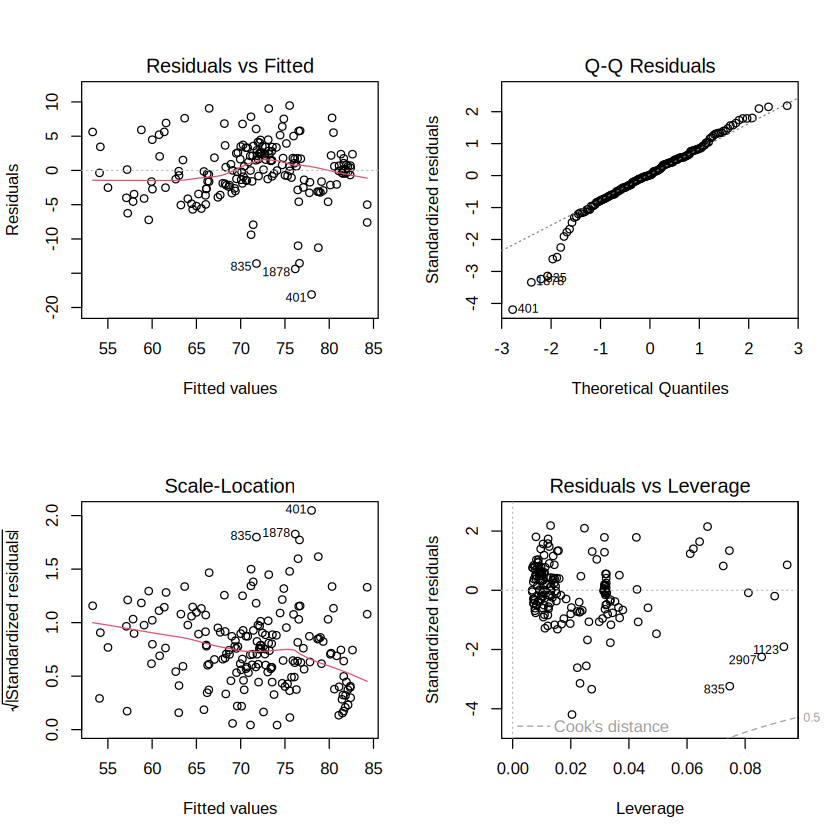

In [42]:
par(mfrow = c(2, 2))
plot(modelo_final)
par(mfrow = c(1, 1))

Esperanza de vida
​=77.73−5.52(Paıˊs en desarrollo)−0.0526(Mortalidad adulta)+0.0788(Hepatitis B).

El modelo es estadísticamente significativo, debido a que su valor p global es menor que 0.05. Su \(R^2\) es 0.7166, por lo que explica aproximadamente el 71.66 % de la variación observada en la esperanza de vida. El \(R^2\) ajustado es 0.7119.

Intercepto (77.73): representa la esperanza de vida estimada para un país desarrollado cuando la mortalidad adulta y la cobertura de vacunación contra hepatitis B son iguales a cero. Aunque ese escenario no sea completamente realista, funciona como punto de referencia matemático del modelo.
Estatus del país (-5.52): manteniendo constantes las demás variables, un país en desarrollo presenta en promedio 5.52 años menos de esperanza de vida que un país desarrollado.
Mortalidad adulta (-0.0526): manteniendo constantes las demás variables, por cada unidad adicional de mortalidad adulta, la esperanza de vida disminuye aproximadamente 0.0526 años.
Hepatitis B (0.0788): manteniendo constantes las demás variables, por cada punto porcentual adicional de cobertura de vacunación contra hepatitis B, la esperanza de vida aumenta aproximadamente 0.0788 años.
Diagnóstico del modelo

Las gráficas de diagnóstico muestran que los residuos siguen aproximadamente una distribución normal, pues la mayoría de los puntos se encuentra cerca de la línea del gráfico Q-Q. Sin embargo, existen algunas desviaciones en los extremos, posibles valores atípicos y cierta variación desigual de los residuos.

La gráfica de residuos contra valores ajustados presenta un patrón ligeramente irregular, por lo que los supuestos de linealidad y varianza constante no se cumplen de manera perfecta. También aparecen algunas observaciones con mayor influencia, las cuales podrían revisarse individualmente. En general, el modelo tiene una capacidad explicativa adecuada, aunque sus resultados deben interpretarse considerando estas limitaciones.